In [134]:
from langchain_ollama import ChatOllama
from typing import TypedDict
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt


In [135]:
class State(TypedDict):
    request:str
    email_draft:str
    approval:str
    result:str

In [136]:
def generate_email(state):
    draft=f""" 
Subject: Request 
Dear Manager,

{state['request']}
Regards,
Employee
"""    
    return{ "email_draft":draft
    }

In [137]:
def approval_node(state:State):
    approval=interrupt(
        {
            "email_draft":state['email_draft'],
            "question":"Approve this email"
        }
    )
    return {
        'approval':approval
    }

In [138]:
def send_mail(state:State):
    if state['approval'].lower()=="yes":
        return {'result':"Email sent sucessfully"}
    return {"result":"Email cancelled"}

In [139]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer=InMemorySaver()

config={'configurable':{"thread_id":"thread-1"}}

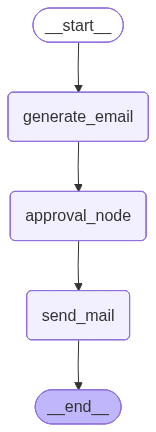

In [140]:
from langgraph.graph import StateGraph,START,END

builder=StateGraph(State)


builder.add_node("generate_email",generate_email)
builder.add_node("approval_node",approval_node)
builder.add_node("send_mail",send_mail)

builder.add_edge(START,"generate_email")
builder.add_edge('generate_email','approval_node')
builder.add_edge('approval_node','send_mail')
builder.add_edge('send_mail',END)

graph1=builder.compile(checkpointer=checkpointer)
graph1

In [141]:
result=graph1.invoke({'request':'I would like take the sick leave tommorow'},config=config)
print(result)

{'request': 'I would like take the sick leave tommorow', 'email_draft': ' \nSubject: Request \nDear Manager,\n\nI would like take the sick leave tommorow\nRegards,\nEmployee\n', '__interrupt__': [Interrupt(value={'email_draft': ' \nSubject: Request \nDear Manager,\n\nI would like take the sick leave tommorow\nRegards,\nEmployee\n', 'question': 'Approve this email'}, id='4e705544b595f810cf6c3797de564f2f')]}


In [142]:
# from langgraph.types import Command

# graph1.invoke( 
#     Command(resume="No"),
#     config=config
# )

In [143]:
from langgraph.types import Command
graph1.invoke(
    Command(resume="YES"),
    config=config
)

{'request': 'I would like take the sick leave tommorow',
 'email_draft': ' \nSubject: Request \nDear Manager,\n\nI would like take the sick leave tommorow\nRegards,\nEmployee\n',
 'approval': 'YES',
 'result': 'Email sent sucessfully'}